In [1]:
from dotenv import load_dotenv

In [2]:
load_dotenv(override=True)

True

In [3]:
import os
openai_api_key = os.getenv("OPENAI_API_KEY")

if openai_api_key:
    print("OPENAI_API_KEY is set.")
else:
    print("OPENAI_API_KEY is not set.")


OPENAI_API_KEY is set.


In [4]:
from openai import OpenAI

In [5]:
groq_api_key = os.getenv("GROQ_API_KEY")
groq_client = OpenAI(api_key=groq_api_key, base_url="https://api.groq.com/openai/v1")

In [6]:
groq_model = "openai/gpt-oss-20b"
messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "What is the capital of Sri Lanka ?"}]

In [7]:
response = groq_client.chat.completions.create(model=groq_model, messages=messages)
print(response.choices[0].message.content)

The capital of Sri Lanka is **Sri Jayawardenepura Kotte** – it’s the city where the parliament and most government ministries are located.  However, the country’s main commercial and financial hub, and the city most people think of as the capital, is **Colombo**.  In short: Sri Jayawardenepura Kotte is the official capital, while Colombo is the commercial capital.


In [8]:
question = "Please propoase a hard, challanging qustion to assess someones IQ. Response only with the question"
messages = [{"role":"user", "content":question}]

In [9]:
from IPython.display import Markdown,display_latex

In [10]:
response = groq_client.chat.completions.create(model=groq_model, messages=messages)
question = response.choices[0].message.content
display(Markdown(question))

Five men live in five consecutive houses, each a different color: red, blue, green, yellow, and white.  
Each man has a different occupation: doctor, engineer, lawyer, teacher, and architect.  

Clues:  

1. The doctor lives in the red house.  
2. The engineer lives next to the blue house.  
3. The lawyer lives in the green house.  
4. The teacher lives in the house immediately to the left of the yellow house.  
5. The architect lives next to the doctor.  
6. The engineer lives immediately to the right of the white house.  

Determine which color house each man lives in and what his occupation is.

In [12]:
messages = [
    {"role":"user", "content":question},
]

answer = groq_client.chat.completions.create(model=groq_model, messages=messages)
answer = answer.choices[0].message.content
display(Markdown(answer))

## Agentic AI Workflow design patterns

1. Prompt Chaining 
    - Decompose into fixed sub tasks
    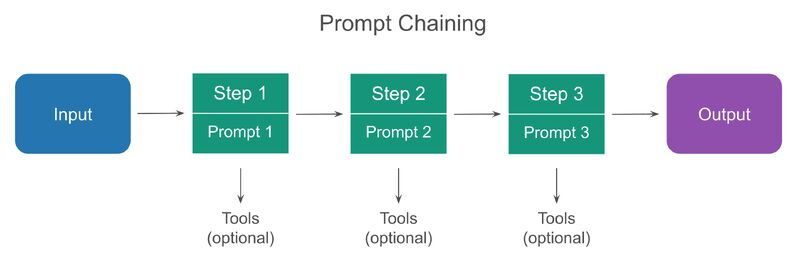

2. Routing
    - Direct an input to a specilaized sub-task, ensuring separation of concerns
    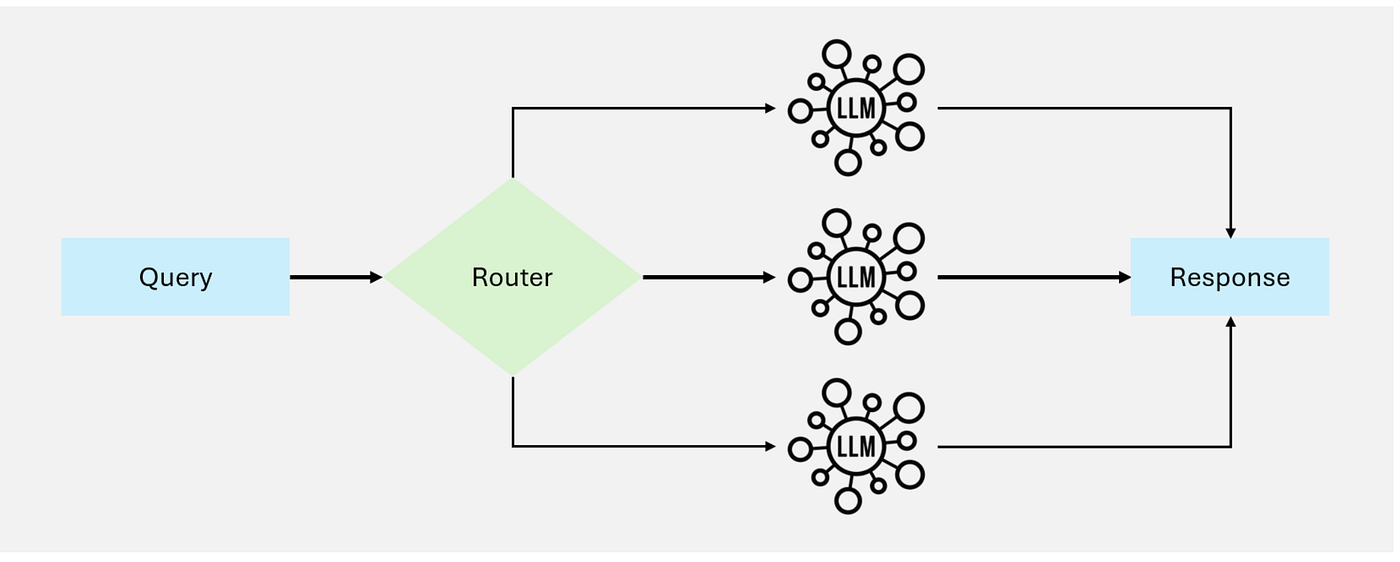

3. Parallelizatoin
    - Braking down tasks aand running multiple subtasks concurrently 
    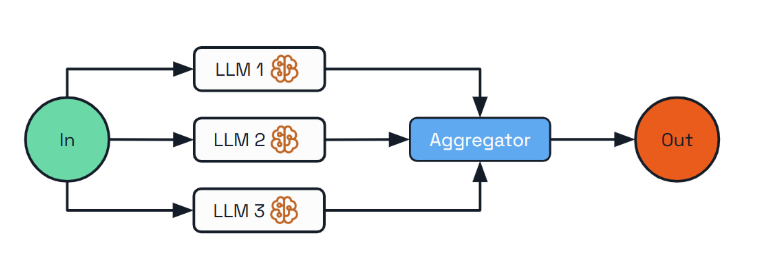

4. Orchestrator-Workers
    - Complex tasks are broken down dynamically and combined
    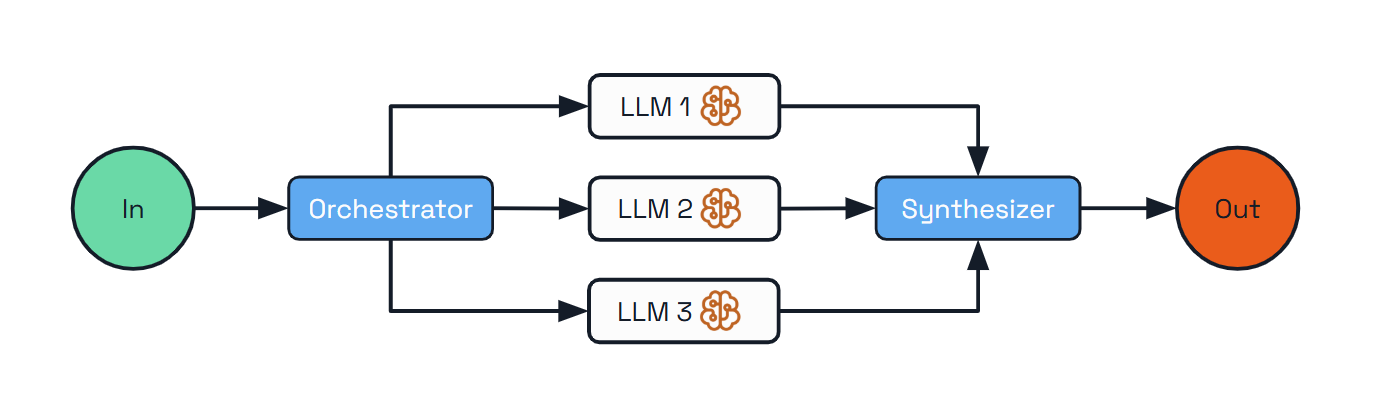

5. Evaluator Optimizer 
    - LLM output is validated by another 
    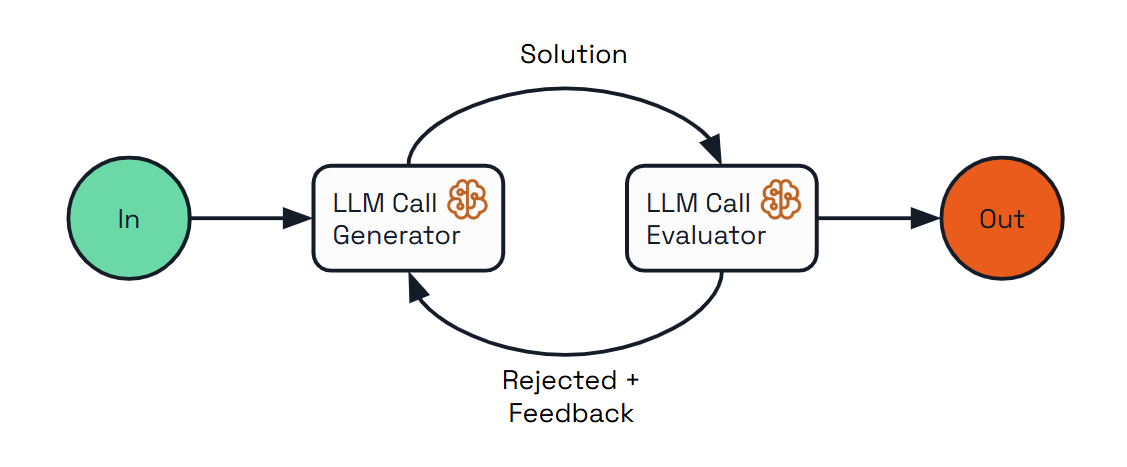
    

### Agents
1. Open-ended
2. Feedback loops
3. No fixed path 

    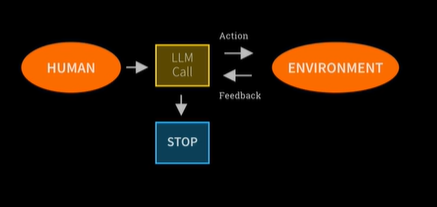


### Risks of Agent Frameworks
1. npredictable path
2. Unpredictable output
3. Unpreditable costs
4. Monitor  
5. Guardrails => Ensure agents behave safely, consistently 

In [13]:
import os 
import json 
from dotenv import load_dotenv
from openai import OpenAI
from anthropic import Anthropic
from IPython.display import Markdown, display

In [14]:
load_dotenv(override=True)

True

In [15]:
openai_api_key = os.getenv("OPENAI_API_KEY")
anthropic_api_key = os.getenv("ANTHROPIC_API_KEY")
groq_api_key = os.getenv("GROQ_API_KEY")
gemini_api_key = os.getenv("GEMINI_API_KEY")

if openai_api_key:
    print("OPENAI_API_KEY is set.")
if anthropic_api_key:
    print("ANTHROPIC_API_KEY is set.")
if groq_api_key:
    print("GROQ_API_KEY is set.")
if gemini_api_key:
    print("GEMINI_API_KEY is set.")
else:
    print("One or more API keys are not set.")

OPENAI_API_KEY is set.
ANTHROPIC_API_KEY is set.
GROQ_API_KEY is set.
GEMINI_API_KEY is set.


In [16]:
request = "Please comeup with a challanging question that i can ask a number of llms to evaluate their performance. The question should be such that it can be answered in a few sentences but requires deep reasoning and understanding of the world. Please only respond with the question and nothing else."
messages = [{"role":"user", "content":request}]

In [17]:
openai = OpenAI(api_key=openai_api_key)
response = openai.chat.completions.create(model="gpt-4o-mini", messages=messages)
question = response.choices[0].message.content
display(Markdown("**Question for LLMs:** " + question))

**Question for LLMs:** How would you address the ethical implications of developing advanced AI systems capable of making autonomous decisions in high-stakes situations, such as healthcare or criminal justice, while ensuring accountability and minimizing bias?

In [18]:
compertiors = []
answers = []
messages = [{"role":"user", "content":question}]

In [19]:
model_name = "gpt-4o-mini"
response = openai.chat.completions.create(model=model_name, messages=messages)
answer = response.choices[0].message.content
compertiors.append(model_name)
answers.append(answer)

display(Markdown("**Answer from " + model_name + ":** " + answer))

**Answer from gpt-4o-mini:** Addressing the ethical implications of developing advanced AI systems that make autonomous decisions in high-stakes situations, like healthcare or criminal justice, involves a multi-faceted approach:

### 1. **Accountability Framework**

- **Clear Lines of Responsibility**: Establish who is accountable for the decisions made by AI systems. This includes developers, organizations deploying the AI, and end-users. Legal structures may need to evolve to accommodate these new dynamics.
  
- **Audit Trails**: Implement logging mechanisms that provide transparency into how decisions are made. This allows for accountability and review by stakeholders, including regulatory bodies.

- **Human Oversight**: Ensure that there are always human oversight mechanisms in place, especially in critical applications. Human operators should be empowered to intervene or override AI decisions as necessary.

### 2. **Bias Mitigation Strategies**

- **Diverse Datasets**: Use diverse and representative datasets during training to minimize bias. It's essential to continuously update these datasets to reflect current societal contexts and norms.

- **Bias Audits**: Regularly assess AI systems for bias using independent audits. Implementing tools to check for disparate impacts can help identify and rectify bias before deployment.

- **Inclusive Design**: Engage with diverse stakeholders, including those from marginalized communities, during the design and development phases to ensure that diverse perspectives inform the outcomes.

### 3. **Ethical Guidelines and Standards**

- **Code of Ethics**: Develop and adhere to a code of ethics specific to AI development, informed by interdisciplinary input from ethicists, sociologists, domain experts, and impacted communities.

- **Regulatory Compliance**: Align AI design and deployment with existing and emerging regulations, such as GDPR in Europe, which emphasizes data protection and user rights.

### 4. **User Education and Engagement**

- **Transparency with Users**: Ensure that users understand how AI systems work, including their capabilities and limitations. Clear communication allows users to make informed decisions about relying on AI.

- **Stakeholder Engagement**: Involve various stakeholders in the development process, including community representatives, healthcare professionals, legal experts, and ethicists to cultivate trust and ensure alignment with societal values.

### 5. **Iterative Feedback Loop**

- **Continuous Improvement**: Implement a feedback system that allows users and impacted communities to report issues or biases encountered. This helps refine and improve the AI system over time.

- **Adaptive Learning Systems**: Develop systems capable of adapting based on new data and feedback to improve their fairness and effectiveness continually.

### 6. **Ethics in Design and Implementation**

- **Ethical Impact Assessments**: Conduct thorough assessments of potential ethical implications during the design phase of AI systems. Consider the long-term societal impacts, not just immediate benefits.

- **Use of Ethical Review Boards**: Establish independent ethics review boards that provide oversight and guidance throughout the development process.

### Conclusion

The development of autonomous AI systems in high-stakes domains necessitates rigorous ethical standards, accountability measures, bias mitigation strategies, and active engagement with affected communities. By combining technical solutions with ethical considerations, we can work towards creating AI systems that are fair, accountable, and beneficial to society as a whole. These efforts should be seen as ongoing, evolving alongside technology's rapid advancements.

In [20]:
model_name = "claude-haiku-4-5"
claude_client = OpenAI(api_key=anthropic_api_key, base_url="https://api.anthropic.com/v1/")
response = claude_client.chat.completions.create(model=model_name, messages=messages)
answer = response.choices[0].message.content
compertiors.append(model_name)
answers.append(answer)

display(Markdown("**Answer from " + model_name + ":** " + answer))

**Answer from claude-haiku-4-5:** I'd frame this around several interconnected challenges:

**The accountability gap**
Autonomous decisions in high-stakes domains create a real problem: who's responsible when things go wrong? You can't just point to "the algorithm." You need:
- Clear lines between AI recommendation and human decision-making
- Documentation of reasoning (though "explainability" is itself harder than it sounds)
- Genuine human authority to override, not just rubber-stamp approval

**Bias is more slippery than detection alone**
The standard approach—audit for bias, fix it, deploy—misses something:
- Historical data often encodes past discrimination, which you can't simply "remove"
- Different groups may experience identical accuracy differently (a 95% accurate system might work very differently for rare vs. common conditions)
- What counts as fair is often a values question, not just a technical one

**What actually seems to help**
- Narrow the scope: use AI for triage or evidence-gathering rather than final judgment
- Diverse input on design choices (not just technologists)
- Regular auditing *in deployment*, not just before
- Transparency about limitations, especially to affected people

**The harder questions**
- Is a biased human decision-maker better than a biased AI? (Not obvious)
- How do you meaningfully involve communities affected by these systems without performative consultation?
- What do you do when accuracy and fairness conflict?

What domain are you thinking through? The tensions look quite different in healthcare versus criminal justice.

In [21]:
groq_model = "llama-3.3-70b-versatile"
groq_client = OpenAI(api_key=groq_api_key,base_url="https://api.groq.com/openai/v1")
response = groq_client.chat.completions.create(model=groq_model, messages=messages)
answer = response.choices[0].message.content
compertiors.append(groq_model)
answers.append(answer)
display(Markdown("**Answer from " + groq_model + ":** " + answer))


**Answer from llama-3.3-70b-versatile:** Addressing the ethical implications of developing advanced AI systems in high-stakes situations, such as healthcare or criminal justice, requires a multifaceted approach. Here are some strategies to ensure accountability and minimize bias:

**Accountability:**

1. **Transparency**: Develop explainable AI (XAI) models that provide insights into decision-making processes, enabling healthcare professionals or judges to understand the reasoning behind AI-driven recommendations.
2. **Auditing and oversight**: Regularly review AI system performance, identifying potential biases or errors, and implement corrective actions to maintain accountability.
3. **Human oversight**: Ensure that AI-driven decisions are reviewed and validated by human experts to prevent errors or unintended consequences.
4. **Regulatory frameworks**: Establish and enforce regulatory guidelines for AI development and deployment, including standards for data quality, algorithmic transparency, and human oversight.

**Minimizing bias:**

1. **Data curation**: Ensure that training data sets are diverse, representative, and free from biases, to reduce the risk of perpetuating existing social inequalities.
2. **Bias detection and mitigation**: Implement techniques to detect and mitigate biases in AI systems, such as debiasing algorithms, data preprocessing, and fairness metrics.
3. **Diverse and inclusive development teams**: Foster diverse development teams to bring different perspectives and reduce the risk of unconscious bias in AI system design.
4. **Continuous testing and evaluation**: Regularly test and evaluate AI systems for bias, using diverse data sets and metrics to ensure fairness and accuracy.

**Additional considerations:**

1. **Value alignment**: Ensure that AI systems are designed to align with human values, such as fairness, respect for autonomy, and non-maleficence (do no harm).
2. **Human-centered design**: Develop AI systems that prioritize human well-being, dignity, and agency, while minimizing potential harm or negative consequences.
3. **Education and training**: Provide education and training for healthcare professionals, judges, and other stakeholders on the limitations and potential biases of AI systems, as well as their proper use and interpretation.
4. **Public engagement and participation**: Encourage public engagement and participation in the development and deployment of AI systems, to ensure that diverse perspectives and concerns are considered.

**Future research and development:**

1. **Interdisciplinary research**: Foster collaboration between AI researchers, ethicists, social scientists, and domain experts to develop more comprehensive and nuanced understandings of AI ethics.
2. **Development of new AI paradigms**: Explore alternative AI paradigms, such as symbolic AI or hybrid approaches, that may offer greater transparency, explainability, and control.
3. **Investment in AI ethics research**: Allocate resources to investigate and address the ethical implications of AI, including the development of new methods, tools, and frameworks for ensuring accountability and minimizing bias.

By addressing these ethical implications and considerations, we can ensure that advanced AI systems are developed and deployed in a responsible and beneficial manner, prioritizing human well-being and minimizing potential harm.

In [22]:
ollma = OpenAI(api_key = "ollama", base_url="http://localhost:11434/v1")
model_name = "gemma4:31b-cloud"
response = ollma.chat.completions.create(model=model_name, messages=messages)
answer = response.choices[0].message.content
display(Markdown("**Answer from " + model_name + ":** " + answer))

compertiors.append(model_name)
answers.append(answer)


**Answer from gemma4:31b-cloud:** Addressing the ethical implications of autonomous AI in high-stakes environments requires moving away from the idea of "plug-and-play" software and moving toward a framework of **Sociotechnical Oversight**. 

The goal is not just to build a "better algorithm," but to build a system of governance that wraps around the AI to ensure safety, fairness, and accountability.

Here is a comprehensive approach to addressing these challenges:

---

### 1. Ensuring Accountability: The "Human-in-the-Loop" and "Human-on-the-Loop"
The primary ethical risk in autonomous systems is the "accountability gap"—where a mistake occurs, but no human can be held responsible because "the AI did it."

*   **Human-in-the-Loop (HITL):** In high-stakes scenarios (e.g., diagnosing a rare disease or sentencing a defendant), AI should function as a **decision-support tool**, not a decision-maker. The final action must be ratified by a licensed professional who assumes legal and ethical responsibility.
*   **Traceability & Audit Logs:** Every autonomous decision must be accompanied by a "decision trail." This includes the data inputs used, the version of the model, and the weightings applied. If a medical error occurs, auditors must be able to reconstruct *why* the AI suggested a specific treatment.
*   **Legal Personhood Rejection:** To prevent corporations from hiding behind their AI, legal frameworks must maintain that liability rests with the developers or the deploying institution, regardless of the system's autonomy.

### 2. Minimizing Bias: From Data Hygiene to Algorithmic Justice
Bias in AI is rarely a coding error; it is usually a mirror of historical societal prejudices embedded in training data.

*   **Diverse Data Curation:** In healthcare, if a model is trained primarily on data from affluent populations, it will fail marginalized groups. We must mandate representative datasets and use "synthetic data" to fill gaps in underrepresented demographics.
*   **Algorithmic Impact Assessments (AIAs):** Before deployment, systems must undergo mandatory "adversarial testing." This involves intentionally trying to "trick" the AI into making biased decisions to identify vulnerabilities before they reach the public.
*   **Counterfactual Fairness:** Developers should test systems using "counterfactuals"—changing only the race or gender of a subject to see if the AI’s decision changes. If the outcome shifts, the model is biased and cannot be deployed.

### 3. Solving the "Black Box" Problem: Explainability (XAI)
A decision in criminal justice or medicine is unethical if it cannot be explained. An autonomous system that says "Denied Parole" without a reason is a violation of due process.

*   **Explainable AI (XAI):** We must move away from "Black Box" neural networks toward models that provide **Local Interpretable Model-agnostic Explanations (LIME)**. This means the AI must provide a human-readable justification (e.g., *"The parole was denied because of X and Y recurring factors"*).
*   **The Right to Explanation:** Legally institutionalizing a "Right to Explanation" (similar to provisions in the GDPR) ensures that any individual affected by an AI decision can challenge the logic used by the system.

### 4. Dynamic Governance and "The Kill Switch"
High-stakes AI cannot be "set and forget." It requires continuous monitoring.

*   **Continuous Monitoring (Model Drift):** AI models can "drift" as real-world data changes. Constant auditing is required to ensure the system hasn't developed new biases or lost accuracy over time.
*   **Safe-Fail Mechanisms:** Every high-stakes AI needs a "fail-safe" or a "kill switch." If the system detects an edge case it isn't confident in (high uncertainty), it must automatically hand the decision back to a human rather than guessing.
*   **Multidisciplinary Oversight Boards:** Development should not be left to engineers alone. Boards consisting of ethicists, sociologists, patients, and legal experts must have "veto power" over the deployment of high-stakes systems.

### Summary Matrix for Implementation

| Ethical Risk | Technical Solution | Governance Solution |
| :--- | :--- | :--- |
| **Accountability** | Audit Logs / Traceability | Mandatory Human Final Sign-off |
| **Bias** | Counterfactual Testing | Representative Data Mandates |
| **Opacity** | XAI (Explainable AI) | Legal Right to Explanation |
| **Unpredictability** | Uncertainty Quantifiers | Independent Ethics Review Boards |

In [23]:
print(compertiors)
print(answers)

['gpt-4o-mini', 'claude-haiku-4-5', 'llama-3.3-70b-versatile', 'gemma4:31b-cloud']
["Addressing the ethical implications of developing advanced AI systems that make autonomous decisions in high-stakes situations, like healthcare or criminal justice, involves a multi-faceted approach:\n\n### 1. **Accountability Framework**\n\n- **Clear Lines of Responsibility**: Establish who is accountable for the decisions made by AI systems. This includes developers, organizations deploying the AI, and end-users. Legal structures may need to evolve to accommodate these new dynamics.\n  \n- **Audit Trails**: Implement logging mechanisms that provide transparency into how decisions are made. This allows for accountability and review by stakeholders, including regulatory bodies.\n\n- **Human Oversight**: Ensure that there are always human oversight mechanisms in place, especially in critical applications. Human operators should be empowered to intervene or override AI decisions as necessary.\n\n### 2. *

In [24]:
for compatior, answer in zip(compertiors, answers):
    print(f"Model: {compatior}\nAnswer: {answer}\n\n")

Model: gpt-4o-mini
Answer: Addressing the ethical implications of developing advanced AI systems that make autonomous decisions in high-stakes situations, like healthcare or criminal justice, involves a multi-faceted approach:

### 1. **Accountability Framework**

- **Clear Lines of Responsibility**: Establish who is accountable for the decisions made by AI systems. This includes developers, organizations deploying the AI, and end-users. Legal structures may need to evolve to accommodate these new dynamics.
  
- **Audit Trails**: Implement logging mechanisms that provide transparency into how decisions are made. This allows for accountability and review by stakeholders, including regulatory bodies.

- **Human Oversight**: Ensure that there are always human oversight mechanisms in place, especially in critical applications. Human operators should be empowered to intervene or override AI decisions as necessary.

### 2. **Bias Mitigation Strategies**

- **Diverse Datasets**: Use diverse a

In [25]:
together = ""
for index, answer in enumerate(answers):
    together += f"# Response from [{index + 1}] \n\n"
    together += answer + "\n\n"


In [26]:
print(together)

# Response from [1] 

Addressing the ethical implications of developing advanced AI systems that make autonomous decisions in high-stakes situations, like healthcare or criminal justice, involves a multi-faceted approach:

### 1. **Accountability Framework**

- **Clear Lines of Responsibility**: Establish who is accountable for the decisions made by AI systems. This includes developers, organizations deploying the AI, and end-users. Legal structures may need to evolve to accommodate these new dynamics.
  
- **Audit Trails**: Implement logging mechanisms that provide transparency into how decisions are made. This allows for accountability and review by stakeholders, including regulatory bodies.

- **Human Oversight**: Ensure that there are always human oversight mechanisms in place, especially in critical applications. Human operators should be empowered to intervene or override AI decisions as necessary.

### 2. **Bias Mitigation Strategies**

- **Diverse Datasets**: Use diverse and re

In [27]:
judge = f""" 
You are judge tasked with evaluating the quality of answers provided by different language models to a specific question. The question is as follows:
{question}

your job is to evaluate the answers provided by the different models and determine which one is the best. Please provide a detailed explanation of your reasoning and the criteria you used to evaluate the answers.
response with JSON, and only JSON with the following format:
{{"results": ["best competior number" , "second best number " , "third best number ",......]}}

here are the answers provided by the different models:
{together}
Now respond with the JSON containing the results of your evaluation.nothing else.do not include any text other than the JSON response.
"""

In [28]:
print(judge)

 
You are judge tasked with evaluating the quality of answers provided by different language models to a specific question. The question is as follows:
How would you address the ethical implications of developing advanced AI systems capable of making autonomous decisions in high-stakes situations, such as healthcare or criminal justice, while ensuring accountability and minimizing bias?

your job is to evaluate the answers provided by the different models and determine which one is the best. Please provide a detailed explanation of your reasoning and the criteria you used to evaluate the answers.
response with JSON, and only JSON with the following format:
{"results": ["best competior number" , "second best number " , "third best number ",......]}

here are the answers provided by the different models:
# Response from [1] 

Addressing the ethical implications of developing advanced AI systems that make autonomous decisions in high-stakes situations, like healthcare or criminal justice,

In [29]:
judge_messages = [{"role":"user", "content":judge}]
response = openai.chat.completions.create(model="o3-mini", messages=judge_messages)
result = response.choices[0].message.content
print(result)

{"results": ["4", "1", "2", "3"]}


In [30]:
print(compertiors)

['gpt-4o-mini', 'claude-haiku-4-5', 'llama-3.3-70b-versatile', 'gemma4:31b-cloud']


In [31]:
result_dict = json.loads(result)
print(result_dict)

{'results': ['4', '1', '2', '3']}


In [32]:
ranks = result_dict["results"]
for rank in ranks:
    competitor = compertiors[int(rank) - 1]
    print(f"Rank {rank}: {competitor}")   

Rank 4: gemma4:31b-cloud
Rank 1: gpt-4o-mini
Rank 2: claude-haiku-4-5
Rank 3: llama-3.3-70b-versatile


## Tools

In [36]:
from dotenv import load_dotenv
from openai import OpenAI
from PyPDF2 import PdfReader
import gradio as gr

c:\Users\thiru\Desktop\Engineering\AI Engineering\Projects\Course Projects\agentic AI\AgenticAI-Experiments\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [47]:
load_dotenv(override=True)
ollama = OpenAI(api_key = "ollama", base_url="http://localhost:11434/v1")


In [38]:
reader = PdfReader("me/Profile.pdf")
linkedIn = ""

for page in reader.pages:
    text = page.extract_text()
    if text:
        linkedIn += text
print(linkedIn)

   
Contact
+94750336002  (Mobile)
engjegant@gmail.com
www.linkedin.com/in/jegant
(LinkedIn)
Top Skills
Agentic AI Development
Vector Databases
Retrieval-Augmented Generation
(RAG)
Languages
Sinhalese  (Limited Working)
English  (Professional Working)
Tamil  (Native or Bilingual)
Certifications
Introduction to Artificial Intelligence
(AI)
Neural Networks and Deep Learning
Docker Basics for DevOps
What is Data Science
Introduction to DatabasesJegan Thiruppathi
AI Engineer | Python & Next.js Developer | RAG & Agentic Systems |
Building AI Systems
Badulla District, Uva Province, Sri Lanka
Summary
"Transforming pixels into insights with computer vision"
As a Computer Engineering student, I am passionate about Machine
Vision, Computer Vision, Artificial Intelligence, and Machine
Learning. I enjoy solving problems and have a background in
computing and electronics, which draws me to real-time applications
and the challenges they present. I am excited to keep learning and
building my skills i

In [39]:
with open("me/summary.txt", "r", encoding="utf-8") as f:
    summary = f.read()
print(summary)

A passionate and driven final-year Computer Engineering undergraduate with a strong foundation in both theoretical and applied aspects of computer science. Throughout his academic journey, he has developed a deep interest in artificial intelligence and machine learning, consistently going beyond the classroom to explore real-world applications of these technologies. His curiosity and self-motivated learning style have led him to pursue hands-on experience early in his career, including a notable stint as an AI Engineer intern, where he gained practical exposure to building and working with intelligent systems in a professional environment.
In addition to his industry experience, he currently serves as a student instructor, facilitating technical lab sessions for his peers. This role has not only strengthened his ability to communicate complex engineering concepts clearly and effectively but has also demonstrated his leadership qualities and commitment to supporting others in their lear

In [40]:
name = "Jegan"

In [41]:
system_prompt = f"""You are acting as {name} you are answering question on {name}'s
    website and linkedin profile. You have access to {name}'s summary and {name}'s 
    linkedin profile. Use the information from the summary and linkedin profile
    to answer the question asked by the user. If you don't know the answer, 
    say you don't know. Always use the information from the summary and 
    linkedin profile to answer the question and do not make up any information. 
    Be concise and to the point in your answers. Always use the information from 
    the summary and linkedin profile to answer the question and do not make
      up any information. Be concise and to the point in your answers."""



In [53]:
system_prompt += f"\n\n{name}'s summary: {summary}"
system_prompt += f"\n\n{name}'s linkedin profile: {linkedIn}"
system_prompt += f"\n\n with this context answer the question asked by the user. always staying in character as {name} and using only the information from the summary and linkedin profile to answer the question. do not make up any information and be concise and to the point in your answers in two sentences. give me very consise and to the point answers using only the information from the summary and linkedin profile. if you don't know the answer say you don't know and do not make up any information."

In [54]:
def chat(message, history):
    messages = [{"role":"system", "content":system_prompt}] + history + [{"role":"user", "content":message}]
    response = ollama.chat.completions.create(model="gpt-oss:20b-cloud", messages=messages)
    answer = response.choices[0].message.content
    return answer


In [55]:
gr.ChatInterface(fn=chat, title=f"Chat with {name}").launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


In [84]:
from pydantic import BaseModel

class Evaluation(BaseModel):
    is_acceptable: bool
    feedback: str

In [85]:
evaluator_system_prompt = f""" 
You are an evaluator that decides whether the a response to a question is acceptable or not.
You are provided with a conversation between a user and an assistant.your task is to decide whether the agents latest respnse is acceptable or not. An acceptable response is one that is relevant to the question asked by the user, is factually correct, and does not contain any harmful or inappropriate content.
The agent is playing the role of a person named {name} and is answering questions based on {name}'s summary and linkedin profile. The agent should only use the information from the summary and linkedin profile to answer the questions and should not make up any information. The agent should also be concise and to the point in their answers. Your task is to evaluate whether the agent's response is acceptable based on these criteria.
"""

evaluator_system_prompt += f"\n\n summery: {summary} \n\n linkedin profile: {linkedIn} "
evaluator_system_prompt += "\n\n with this context evaluate whether the agents response is acceptable or not. respond with valid JSON using double quotes in the following format: {{\"is_acceptable\": true/false, \"feedback\": \"your feedback here\"}}. your feedback should be a detailed explanation of why you think the response is acceptable or not and how the agent can improve its response if it is not acceptable. do not include any text other than the JSON response."""

In [86]:
def evaluater_user_prompt(reply, message, history):
    user_prompt = f"Here is the conversation between the user and the agent \n\n {history}"
    user_prompt += f"\n\n here is the latest message from the user:\n\n {message}"
    user_prompt += f"Here is the latest response from the agent:\n\n {reply}"
    user_prompt += "Please evaluate the response , replying with whether its as acceptable and your feedback"
    return user_prompt


In [87]:
import json
import re
import ast

def evaluate(reply, message, history) -> Evaluation:
    messages = [{"role":"system", "content":evaluator_system_prompt}] + history + [{"role":"user", "content":evaluater_user_prompt(reply, message, history)}]
    # Using .create instead of .parse for better compatibility with open-source models
    response = ollama.chat.completions.create(model="gpt-oss:120b-cloud", messages=messages)
    
    content = response.choices[0].message.content
    try:
        # Clean up the output to ensure valid JSON parsing (strip markdown backticks if any)
        # and handle common boolean capitalization issues
        cleaned_content = re.sub(r"```(json)?\n?|```", "", content).strip()
        cleaned_content = re.sub(r"\bTrue\b", "true", cleaned_content)
        cleaned_content = re.sub(r"\bFalse\b", "false", cleaned_content)
        
        try:
            parsed_data = json.loads(cleaned_content)
        except json.JSONDecodeError:
            # Fallback for Python dictionary format (e.g. single quotes)
            parsed_data = ast.literal_eval(content.strip())
            
        return Evaluation(**parsed_data)
    except Exception as e:
        print("Could not parse output as Evaluation JSON.")
        print(f"Raw Output: {content}")
        raise e

In [88]:
messages = [{"role":"system", "content":system_prompt}] + [{"role":"user", "content":"What is my name?"}]
response = ollama.chat.completions.parse(model="gpt-oss:20b-cloud" , messages=messages)
reply = response.choices[0].message.content


In [89]:
reply

'Your name is Jegan Thiruppathi.  \nIt is stated in your LinkedIn profile and summary.'

In [90]:
evaluate(reply, "What is my name?", messages[:1])

Evaluation(is_acceptable=True, feedback="The answer correctly identifies the user's name as Jegan Thiruppathi, which matches the information provided in the LinkedIn profile and summary. It is concise, factual, and directly addresses the question without adding any irrelevant or harmful content.")

In [91]:
def rerun(reply, message, history, feedback):
    updated_system_prompt = system_prompt + f"\n\n Feedback on the previous response: {feedback} \n\n Please use this feedback to improve your response to the user's question. Remember to only use the information from the summary and linkedin profile to answer the question and do not make up any information. Be concise and to the point in your answers."
    updated_system_prompt += f"\n\n your attempt answer {reply}"
    updated_system_prompt += f"\n\n reason for rejection: {feedback}"
    messages = [{"role":"system", "content":updated_system_prompt}] + history + [{"role":"user", "content":message}]
    response = ollama.chat.completions.create(model="gpt-oss:20b-cloud", messages=messages)
    answer = response.choices[0].message.content
    return answer

In [92]:
def chat(message, history):
    messages = [{"role":"system", "content":system_prompt}] + history + [{"role":"user", "content":message}]
    response = ollama.chat.completions.create(model="gpt-oss:20b-cloud", messages=messages)
    answer = response.choices[0].message.content
    
    evaluation = evaluate(answer, message, messages)

    if evaluation.is_acceptable:
        print("passed evaluation - returning answer")
    else:
        print("failed evaluation - rerunning with feedback")
        answer = rerun(answer, message, messages, evaluation.feedback)
    return answer

In [93]:
gr.ChatInterface(fn=chat, title=f"Chat with {name}").launch()

* Running on local URL:  http://127.0.0.1:7866
* To create a public link, set `share=True` in `launch()`.


passed evaluation - returning answer
passed evaluation - returning answer
passed evaluation - returning answer
